# YOLO11 Apple Disease Classification

In [1]:
# !gdown 1v4hyiDc2vNzGRPu76nNCOIlfADb9DsQe
# !unrar x -o+ -y "/content/apple-classification.rar" /content/
!pip -q install ultralytics

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.


In [1]:
import subprocess, sys, os
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "--upgrade", "--force-reinstall",
    "numpy==1.26.4",
    "pandas==2.2.2",
    "ultralytics",
])

print("Packages installed. Restarting runtime...")

try:
    # Colab
    from google.colab import runtime
    runtime.unassign()  # restarts and continues to next cell
except ImportError:
    from IPython import get_ipython
    get_ipython().kernel.do_shutdown(restart=True)

Done. NOW restart the runtime before running the next cell.


In [1]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"]     = "offline"

import math, json, random, shutil, warnings
from pathlib import Path
from collections import Counter
import pandas as pd
import cv2
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from tqdm.auto import tqdm
from ultralytics import YOLO

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
DEVICE: cuda
NumPy: 1.26.4
Pandas: 2.2.2


In [2]:
SOURCE_ROOT = "/content/Apple Disease Dataset/Augmentation"
WORK_ROOT   = "/content/yolo11_cls_work"
SPLIT_ROOT  = f"{WORK_ROOT}/split_dataset"

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

MODEL_NAME  = "yolo11s-cls.pt"
IMG_SIZE    = 224
EPOCHS      = 30
BATCH_SIZE  = 64
LR0         = 1e-3
DROPOUT     = 0.15
PATIENCE    = 10
WORKERS     = 2

N_BOOTSTRAPS    = 2000
BOOTSTRAP_SEED  = 123
N_GRADCAM_IMAGES = 12
GRADCAM_ALPHA   = 0.42

os.makedirs(WORK_ROOT, exist_ok=True)
print("SOURCE_ROOT:", SOURCE_ROOT)
print("WORK_ROOT  :", WORK_ROOT)
print("SPLIT_ROOT :", SPLIT_ROOT)

SOURCE_ROOT: /content/Apple Disease Dataset/Augmentation
WORK_ROOT  : /content/yolo11_cls_work
SPLIT_ROOT : /content/yolo11_cls_work/split_dataset


In [3]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def split_classification_dataset(source_root, split_root,
                                  train_ratio=0.7, val_ratio=0.15,
                                  test_ratio=0.15, seed=42):
    source_root = Path(source_root)
    split_root  = Path(split_root)

    assert source_root.exists(), f"Source folder not found: {source_root}"
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8, "Ratios must sum to 1."

    if split_root.exists():
        shutil.rmtree(split_root)

    for split in ["train", "val", "test"]:
        (split_root / split).mkdir(parents=True, exist_ok=True)

    class_dirs = sorted([d for d in source_root.iterdir() if d.is_dir()], key=lambda x: x.name)
    assert len(class_dirs) > 1, "Need at least 2 class folders."

    rng  = random.Random(seed)
    rows = []

    for class_dir in class_dirs:
        images = sorted([p for p in class_dir.iterdir()
                         if p.is_file() and p.suffix.lower() in IMG_EXTS])
        if len(images) == 0:
            print(f"Skipping empty class folder: {class_dir.name}")
            continue

        rng.shuffle(images)
        n = len(images)

        n_train = max(1, int(round(n * train_ratio)))
        n_val   = max(1, int(round(n * val_ratio)))
        n_test  = n - n_train - n_val

        if n_test < 1:
            n_test = 1
            if n_train > n_val and n_train > 1:
                n_train -= 1
            elif n_val > 1:
                n_val -= 1

        while n_train + n_val + n_test > n:
            if n_train > 1:   n_train -= 1
            elif n_val > 1:   n_val   -= 1
            else:             n_test  -= 1

        train_imgs = images[:n_train]
        val_imgs   = images[n_train:n_train + n_val]
        test_imgs  = images[n_train + n_val:]

        for split_name, split_imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
            out_dir = split_root / split_name / class_dir.name
            out_dir.mkdir(parents=True, exist_ok=True)
            for src in split_imgs:
                shutil.copy2(src, out_dir / src.name)

        rows.append({"class": class_dir.name, "total": n,
                     "train": len(train_imgs), "val": len(val_imgs), "test": len(test_imgs)})

    return pd.DataFrame(rows)


split_df = split_classification_dataset(
    SOURCE_ROOT, SPLIT_ROOT,
    train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO, seed=SEED
)
display(split_df)

,class,total,train,val,test
0,Anthracnose,1778,1245,267,266
1,Black Pox,1778,1245,267,266
2,Black Rot,1778,1245,267,266
3,Healthy,1778,1245,267,266
4,Powdery Mildew,1778,1245,267,266


In [4]:
train_dir = Path(SPLIT_ROOT) / "train"
val_dir   = Path(SPLIT_ROOT) / "val"
test_dir  = Path(SPLIT_ROOT) / "test"

classes      = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

train_counts = {c: len(list((train_dir / c).glob("*"))) for c in classes}
val_counts   = {c: len(list((val_dir   / c).glob("*"))) for c in classes}
test_counts  = {c: len(list((test_dir  / c).glob("*"))) for c in classes}

stats_df = pd.DataFrame({
    "class": classes,
    "train": [train_counts[c] for c in classes],
    "val"  : [val_counts[c]   for c in classes],
    "test" : [test_counts[c]  for c in classes],
})
stats_df["total"] = stats_df[["train", "val", "test"]].sum(axis=1)
display(stats_df)
print("Classes:", classes)

,class,train,val,test,total
0,Anthracnose,1245,267,266,1778
1,Black Pox,1245,267,266,1778
2,Black Rot,1245,267,266,1778
3,Healthy,1245,267,266,1778
4,Powdery Mildew,1245,267,266,1778


Classes: ['Anthracnose', 'Black Pox', 'Black Rot', 'Healthy', 'Powdery Mildew']


In [5]:
model = YOLO(MODEL_NAME)

train_results = model.train(
    data      = SPLIT_ROOT,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    project   = "yolo11_cls_runs",
    name      = "yolo11_cls_default",
    pretrained= True,
    optimizer = "AdamW",
    lr0       = LR0,
    dropout   = DROPOUT,
    patience  = PATIENCE,
    workers   = WORKERS,
    seed      = SEED,
    deterministic = True,
    verbose   = True,
    close_mosaic = 0,
    plots     = True,
)

save_dir = Path(model.trainer.save_dir)
print("Training finished. save_dir:", save_dir)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo11_cls_work/split_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.15, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_cls_default, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, ove

In [6]:
best_model_path = save_dir / "weights" / "best.pt"
last_model_path = save_dir / "weights" / "last.pt"

print("best.pt:", best_model_path)
print("last.pt:", last_model_path)
assert best_model_path.exists(), "best.pt not found — check save_dir"

best_model = YOLO(str(best_model_path))
print("Loaded best model.")

best.pt: /content/runs/classify/yolo11_cls_runs/yolo11_cls_default/weights/best.pt
last.pt: /content/runs/classify/yolo11_cls_runs/yolo11_cls_default/weights/last.pt
Loaded best model.


In [7]:
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

test_dataset = datasets.ImageFolder(root=str(test_dir), transform=test_tfms)
test_loader  = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = WORKERS,
    pin_memory  = True,
)

assert test_dataset.classes == classes, "Class order mismatch between test set and training set!"
print(f"Test samples: {len(test_dataset)}")

Test samples: 1330


In [8]:
def predict_probs_yolo_cls(yolo_model, dataloader, device="cuda"):
    net = yolo_model.model.to(device).eval()
    all_probs, all_preds, all_targets, all_paths = [], [], [], []
    sample_paths = [s[0] for s in dataloader.dataset.samples]
    ptr = 0

    with torch.no_grad():
        for imgs, targets in tqdm(dataloader, desc="Testing"):
            imgs   = imgs.to(device, non_blocking=True)
            logits = net(imgs)
            if isinstance(logits, (list, tuple)):
                logits = logits[0] if torch.is_tensor(logits[0]) else logits[1]

            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            bs    = imgs.size(0)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_targets.append(targets.numpy())
            all_paths.extend(sample_paths[ptr:ptr + bs])
            ptr += bs

    return (
        np.concatenate(all_probs),
        np.concatenate(all_preds),
        np.concatenate(all_targets),
        all_paths,
    )


probs, y_pred, y_true, test_paths = predict_probs_yolo_cls(best_model, test_loader, device=DEVICE)

Testing:   0%|          | 0/21 [00:00<?, ?it/s]

In [9]:
acc = accuracy_score(y_true, y_pred)
prec_macro,    rec_macro,    f1_macro,    _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

print(f"Test Accuracy      : {acc:.4f}")
print(f"Macro Precision    : {prec_macro:.4f}")
print(f"Macro Recall       : {rec_macro:.4f}")
print(f"Macro F1           : {f1_macro:.4f}")
print(f"Weighted Precision : {prec_weighted:.4f}")
print(f"Weighted Recall    : {rec_weighted:.4f}")
print(f"Weighted F1        : {f1_weighted:.4f}")

report_txt  = classification_report(y_true, y_pred, target_names=classes, zero_division=0)
report_dict = classification_report(y_true, y_pred, target_names=classes, output_dict=True, zero_division=0)
report_df   = pd.DataFrame(report_dict).T
print(report_txt)
display(report_df)

Test Accuracy      : 0.9789
Macro Precision    : 0.9791
Macro Recall       : 0.9789
Macro F1           : 0.9789
Weighted Precision : 0.9791
Weighted Recall    : 0.9789
Weighted F1        : 0.9789
                precision    recall  f1-score   support

   Anthracnose       0.94      0.97      0.96       266
     Black Pox       0.99      1.00      1.00       266
     Black Rot       0.97      0.93      0.95       266
       Healthy       1.00      0.99      1.00       266
Powdery Mildew       0.99      1.00      1.00       266

      accuracy                           0.98      1330
     macro avg       0.98      0.98      0.98      1330
  weighted avg       0.98      0.98      0.98      1330



,precision,recall,f1-score,support
Anthracnose,0.941606,0.969925,0.955556,266.000000
Black Pox,0.992537,1.000000,0.996255,266.000000
Black Rot,0.968750,0.932331,0.950192,266.000000
Healthy,1.000000,0.992481,0.996226,266.000000
Powdery Mildew,0.992537,1.000000,0.996255,266.000000
accuracy,0.978947,0.978947,0.978947,0.978947
macro avg,0.979086,0.978947,0.978897,1330.000000
weighted avg,0.979086,0.978947,0.978897,1330.000000


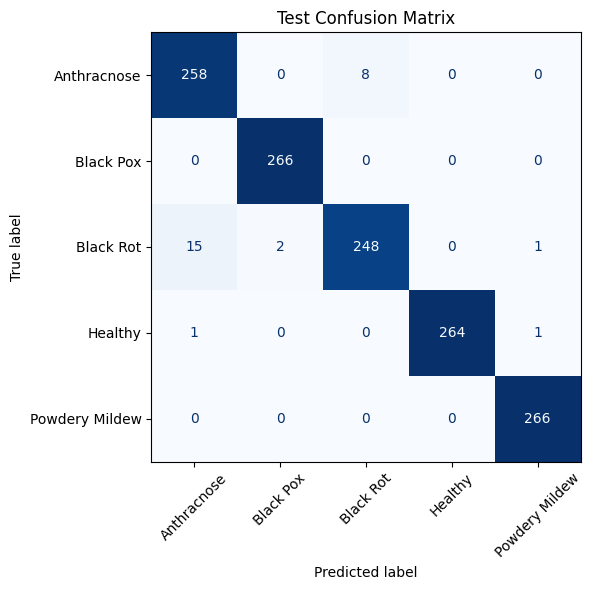

In [10]:
cm  = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(max(8, len(classes) * 0.8), max(6, len(classes) * 0.8)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", values_format="d", colorbar=False)
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.savefig(save_dir / "paper_confusion_matrix.png", dpi=220, bbox_inches="tight")
plt.show()

In [11]:
eval_dir = save_dir / "test_evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)

report_df.to_csv(eval_dir / "classification_report.csv", index=True)
with open(eval_dir / "classification_report.txt", "w") as f:
    f.write(report_txt)

plt.figure(figsize=(max(8, len(classes) * 0.8), max(6, len(classes) * 0.8)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=plt.gca(), xticks_rotation=45, cmap="Blues", values_format="d", colorbar=False)
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.savefig(eval_dir / "confusion_matrix.png", dpi=220, bbox_inches="tight")
plt.close()

pred_df = pd.DataFrame({
    "path"      : test_paths,
    "true_idx"  : y_true,
    "pred_idx"  : y_pred,
    "true_label": [classes[i] for i in y_true],
    "pred_label": [classes[i] for i in y_pred],
    "confidence": probs.max(axis=1),
})
for i, cls_name in enumerate(classes):
    pred_df[f"prob_{cls_name}"] = probs[:, i]

pred_df.to_csv(eval_dir / "test_predictions.csv", index=False)
print("Saved test evaluation outputs to:", eval_dir)

Saved test evaluation outputs to: /content/runs/classify/yolo11_cls_runs/yolo11_cls_default/test_evaluation


Bootstrapping:   0%|          | 0/2000 [00:00<?, ?it/s]

,metric,point_estimate,mean_bootstrap,ci_lower_95,ci_upper_95,std_bootstrap
0,accuracy,0.978947,0.978888,0.970677,0.986466,0.004018
1,precision_macro,0.979086,0.979036,0.970919,0.986252,0.003933
2,recall_macro,0.978947,0.978935,0.970956,0.986060,0.003912
3,f1_macro,0.978897,0.978823,0.970565,0.986121,0.003964
4,precision_weighted,0.979086,0.979113,0.970932,0.986512,0.003945
5,recall_weighted,0.978947,0.978888,0.970677,0.986466,0.004018
6,f1_weighted,0.978897,0.978838,0.970563,0.986435,0.004036


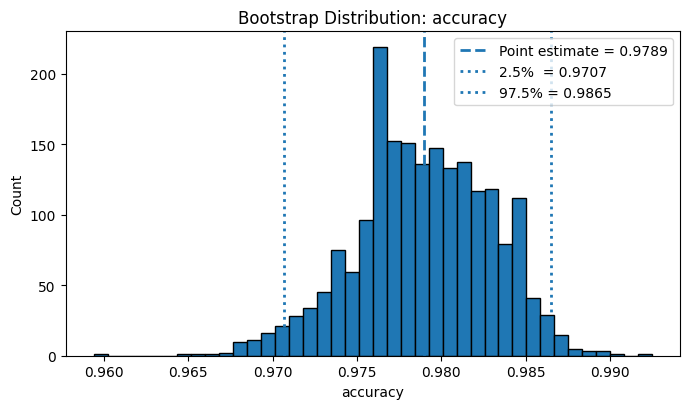

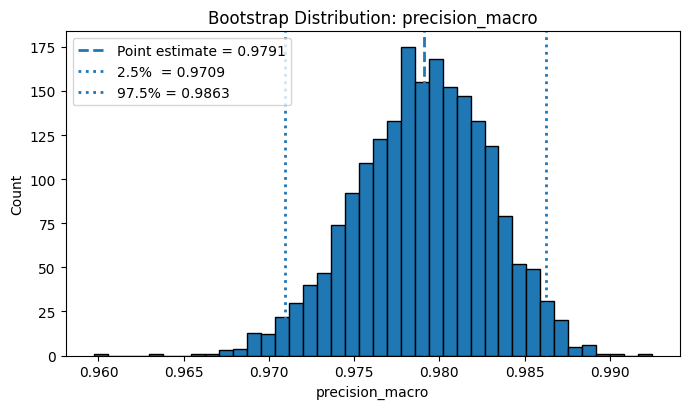

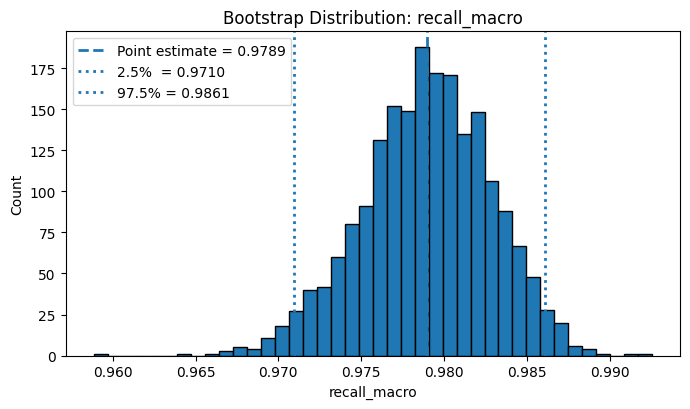

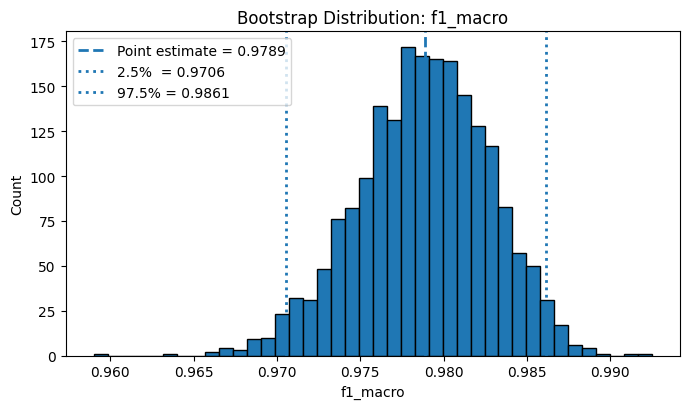

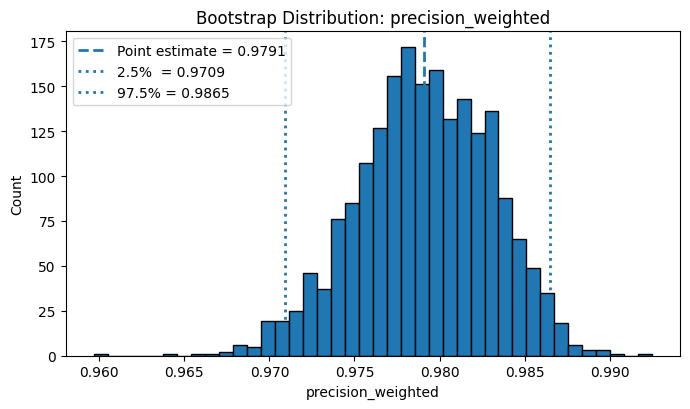

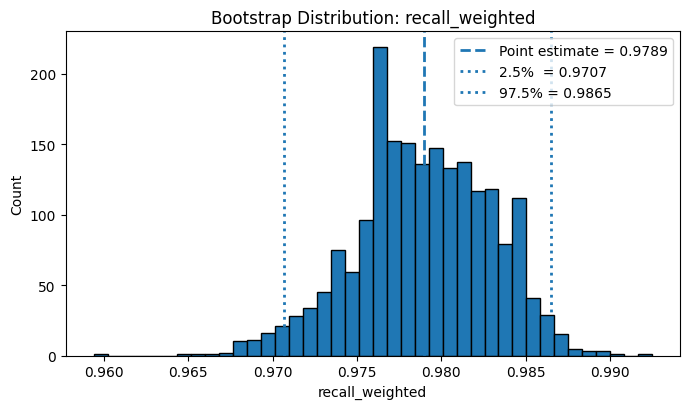

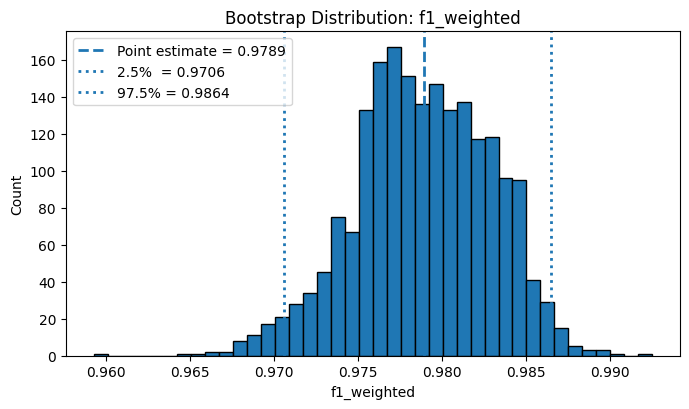

Saved bootstrap outputs to: /content/runs/classify/yolo11_cls_runs/yolo11_cls_default/bootstrap


In [12]:
rng = np.random.default_rng(BOOTSTRAP_SEED)
n   = len(y_true)

def compute_metrics(y_t, y_p):
    acc_ = accuracy_score(y_t, y_p)
    p_m,  r_m,  f1_m,  _ = precision_recall_fscore_support(y_t, y_p, average="macro",    zero_division=0)
    p_w,  r_w,  f1_w,  _ = precision_recall_fscore_support(y_t, y_p, average="weighted", zero_division=0)
    return {"accuracy": acc_,
            "precision_macro": p_m, "recall_macro": r_m, "f1_macro": f1_m,
            "precision_weighted": p_w, "recall_weighted": r_w, "f1_weighted": f1_w}

point_metrics = compute_metrics(y_true, y_pred)

boot_metrics = []
for _ in tqdm(range(N_BOOTSTRAPS), desc="Bootstrapping"):
    idx = rng.integers(0, n, size=n)
    boot_metrics.append(compute_metrics(y_true[idx], y_pred[idx]))

boot_df = pd.DataFrame(boot_metrics)

summary_rows = []
for col in boot_df.columns:
    vals = boot_df[col].values
    summary_rows.append({
        "metric"         : col,
        "point_estimate" : point_metrics[col],
        "mean_bootstrap" : vals.mean(),
        "ci_lower_95"    : np.percentile(vals, 2.5),
        "ci_upper_95"    : np.percentile(vals, 97.5),
        "std_bootstrap"  : vals.std(ddof=1),
    })

bootstrap_summary_df = pd.DataFrame(summary_rows)
display(bootstrap_summary_df)

bootstrap_dir = save_dir / "bootstrap"
bootstrap_dir.mkdir(parents=True, exist_ok=True)

bootstrap_summary_df.to_csv(bootstrap_dir / "bootstrap_confidence_intervals.csv", index=False)
boot_df.to_csv(bootstrap_dir / "bootstrap_all_samples.csv", index=False)

with open(bootstrap_dir / "bootstrap_report.txt", "w") as f:
    f.write("Bootstrap Confidence Interval Report (95%)\n" + "=" * 60 + "\n\n")
    for _, row in bootstrap_summary_df.iterrows():
        f.write(f"{row['metric']}: point={row['point_estimate']:.4f}, "
                f"mean={row['mean_bootstrap']:.4f}, "
                f"95% CI=({row['ci_lower_95']:.4f}, {row['ci_upper_95']:.4f}), "
                f"std={row['std_bootstrap']:.4f}\n")

for metric in boot_df.columns:
    plt.figure(figsize=(7, 4.2))
    plt.hist(boot_df[metric], bins=40, edgecolor="black")
    pe = point_metrics[metric]
    lo = np.percentile(boot_df[metric], 2.5)
    hi = np.percentile(boot_df[metric], 97.5)
    plt.axvline(pe, linestyle="--", linewidth=2, label=f"Point estimate = {pe:.4f}")
    plt.axvline(lo, linestyle=":",  linewidth=2, label=f"2.5%  = {lo:.4f}")
    plt.axvline(hi, linestyle=":",  linewidth=2, label=f"97.5% = {hi:.4f}")
    plt.title(f"Bootstrap Distribution: {metric}")
    plt.xlabel(metric); plt.ylabel("Count"); plt.legend()
    plt.tight_layout()
    plt.savefig(bootstrap_dir / f"{metric}_bootstrap_hist.png", dpi=220, bbox_inches="tight")
    plt.show()

print("Saved bootstrap outputs to:", bootstrap_dir)

Grad-CAM target layer: model.10.conv.conv


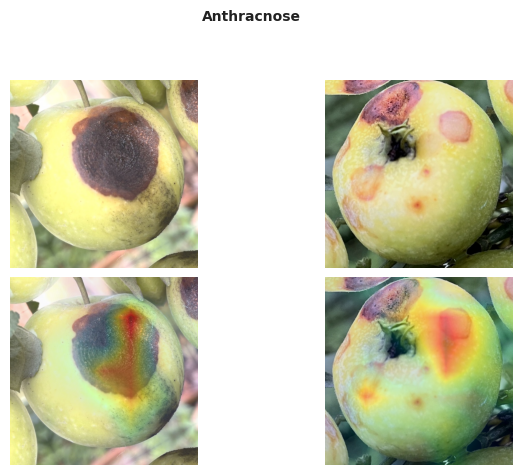

✓ Anthracnose


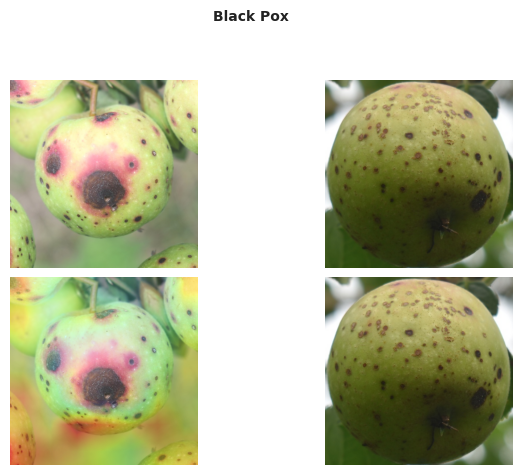

✓ Black Pox


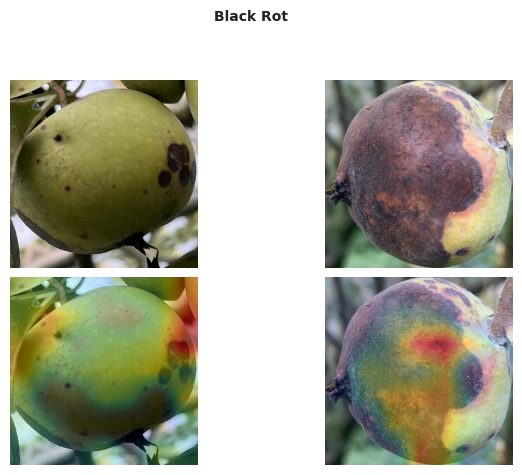

✓ Black Rot


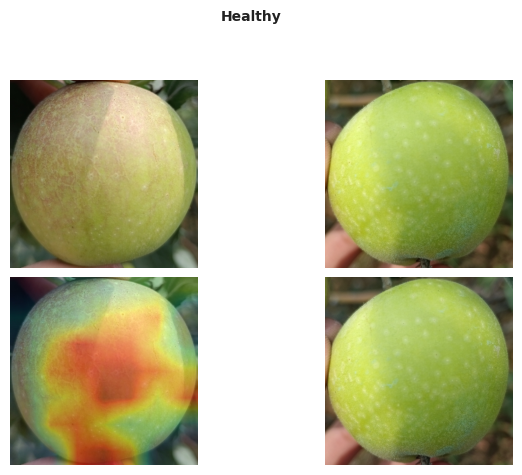

✓ Healthy


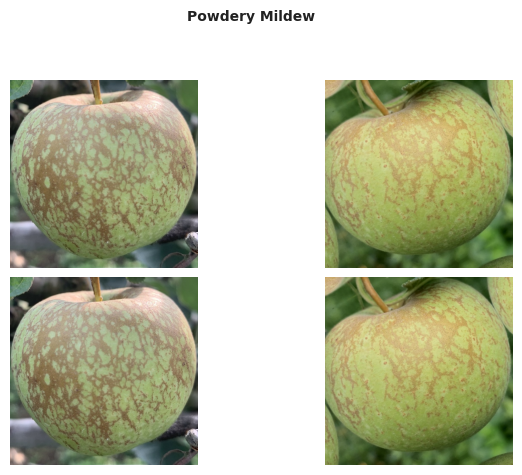

✓ Powdery Mildew


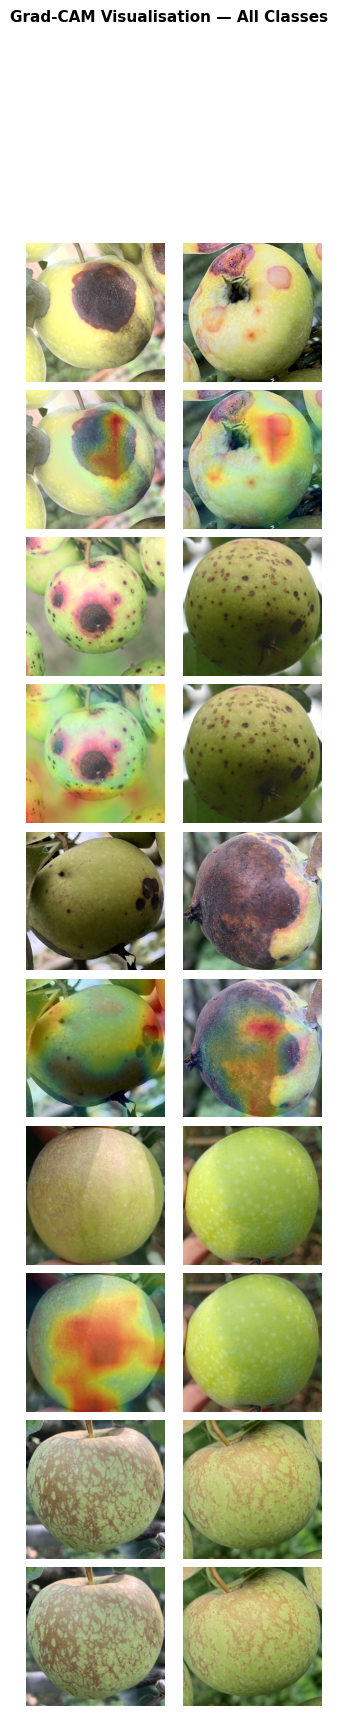


All outputs saved to: /content/runs/classify/yolo11_cls_runs/yolo11_cls_default/gradcam_paper
  • Per-class PDF+PNG : class_<name>.pdf / .png
  • Combined PDF+PNG  : all_classes_combined.pdf / .png  ← use in paper


In [13]:
gradcam_dir = save_dir / "gradcam_paper"
gradcam_dir.mkdir(parents=True, exist_ok=True)

net = best_model.model.to(DEVICE).eval()

target_layer_name = "model.10.conv.conv"
target_layer      = dict(net.named_modules())[target_layer_name]
print("Grad-CAM target layer:", target_layer_name)

IMGS_PER_CLASS = 2      # 2 cols × 2 rows
NCOLS          = 2
ALPHA_MAX      = 0.50    # 0.35 = subtle  |  0.65 = vivid
CMAP           = "jet"   # try 'inferno' or 'plasma' for print


class GradCAM:
    def __init__(self, model, layer):
        self.model       = model
        self.layer       = layer
        self.activations = None
        self.gradients   = None
        h1 = layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach()))
        h2 = layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0].detach()))
        self._hooks = [h1, h2]

    def __call__(self, x, class_idx=None):
        with torch.enable_grad():
            x = x.requires_grad_(True)
            self.model.zero_grad(set_to_none=True)
            out = self.model(x)
            if isinstance(out, (list, tuple)):
                out = out[0] if torch.is_tensor(out[0]) else out[1]
            if class_idx is None:
                class_idx = out.argmax(dim=1).item()
            out[:, class_idx].sum().backward(retain_graph=True)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * self.activations).sum(dim=1))[0].cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def preprocess_pil(img_pil, size=224):
    return transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
    ])(img_pil).unsqueeze(0)


def make_overlay(rgb_img, cam, alpha_max=0.50, cmap="jet"):
    h, w         = rgb_img.shape[:2]
    cam_r        = cv2.resize(cam, (w, h))
    rgba         = plt.get_cmap(cmap)(cam_r).copy()
    rgba[..., 3] = cam_r * alpha_max
    return rgba


def save_fig(fig, path_no_ext):
    for ext in ("pdf", "png"):
        fig.savefig(f"{path_no_ext}.{ext}",
                    dpi=300, bbox_inches="tight", facecolor="white")


gradcam = GradCAM(net, target_layer)

class_to_paths = {c: [] for c in classes}
for path, label_idx in test_dataset.samples:
    class_to_paths[idx_to_class[label_idx]].append(path)


all_class_data = []

for cls_name in classes:
    paths = class_to_paths[cls_name].copy()
    random.Random().shuffle(paths)
    selected_paths = paths[:IMGS_PER_CLASS]

    entries = []
    for path in selected_paths:
        img_pil      = Image.open(path).convert("RGB")
        input_tensor = preprocess_pil(img_pil, IMG_SIZE).to(DEVICE)

        with torch.no_grad():
            out = net(input_tensor)
            if isinstance(out, (list, tuple)):
                out = out[0] if torch.is_tensor(out[0]) else out[1]
            probs_    = torch.softmax(out, dim=1)
            pred_idx_ = probs_.argmax(dim=1).item()
            conf_     = probs_[0, pred_idx_].item()

        cam, _ = gradcam(input_tensor, class_idx=pred_idx_)
        rgb     = np.array(img_pil)
        overlay = make_overlay(rgb, cam, alpha_max=ALPHA_MAX, cmap=CMAP)

        entries.append({
            "rgb"       : rgb,
            "overlay"   : overlay,
            "pred_label": idx_to_class[pred_idx_],
            "conf"      : conf_,
            "correct"   : idx_to_class[pred_idx_] == cls_name,
        })

    all_class_data.append((cls_name, entries))

    fig, axes = plt.subplots(
        2, NCOLS,
        # figsize=(NCOLS * 2.0, 4.0),
        gridspec_kw={"hspace": 0.05, "wspace": 0.03}, figsize=(8, 5)
    )
    fig.patch.set_facecolor("white")

    for col, e in enumerate(entries):
        color = "#27ae60" if e["correct"] else "#c0392b"

        axes[0, col].imshow(e["rgb"])
        axes[0, col].axis("off")

        axes[1, col].imshow(e["rgb"])
        axes[1, col].imshow(e["overlay"])
        # axes[1, col].set_title(f"{e['conf']:.2f}", fontsize=8, color=color, pad=2)
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=8, color="#444", labelpad=4)
    axes[1, 0].set_ylabel("Grad-CAM", fontsize=8, color="#444", labelpad=4)
    fig.suptitle(cls_name.replace("_", " "), fontsize=10,
                 fontweight="bold", y=1.02, color="#222")

    save_fig(fig, gradcam_dir / f"class_{cls_name}")
    plt.show()
    plt.close()
    print(f"✓ {cls_name}")


n_classes   = len(classes)
nrows_total = n_classes * 2

fig, axes = plt.subplots(
    nrows_total, NCOLS,
    figsize=(NCOLS * 2.0, n_classes * 3.8),
    gridspec_kw={"hspace": 0.06, "wspace": 0.03}
)
fig.patch.set_facecolor("white")

for cls_idx, (cls_name, entries) in enumerate(all_class_data):
    row_orig    = cls_idx * 2
    row_overlay = cls_idx * 2 + 1

    for col, e in enumerate(entries):
        color = "#27ae60" if e["correct"] else "#c0392b"

        axes[row_orig, col].imshow(e["rgb"])
        axes[row_orig, col].axis("off")

        axes[row_overlay, col].imshow(e["rgb"])
        axes[row_overlay, col].imshow(e["overlay"])
        # axes[row_overlay, col].set_title(f"{e['conf']:.2f}", fontsize=7, color=color, pad=2)
        axes[row_overlay, col].axis("off")

    axes[row_orig, 0].set_ylabel(
        cls_name.replace("_", "\n"),
        fontsize=7.5, fontweight="bold", color="#222",
        labelpad=5, rotation=0, ha="right", va="center"
    )

    if cls_idx < n_classes - 1:
        for col in range(NCOLS):
            for spine in axes[row_overlay, col].spines.values():
                spine.set_visible(False)
            axes[row_overlay, col].spines["bottom"].set_visible(True)
            axes[row_overlay, col].spines["bottom"].set_linewidth(0.6)
            axes[row_overlay, col].spines["bottom"].set_color("#cccccc")

plt.suptitle("Grad-CAM Visualisation — All Classes",
             fontsize=11, fontweight="bold", y=1.003)

save_fig(fig, gradcam_dir / "all_classes_combined")
plt.show()
plt.close()

print("\nAll outputs saved to:", gradcam_dir)
print("  • Per-class PDF+PNG : class_<name>.pdf / .png")
print("  • Combined PDF+PNG  : all_classes_combined.pdf / .png  ← use in paper")

In [14]:
report_dir = save_dir / "final_report"
report_dir.mkdir(parents=True, exist_ok=True)

lines = [
    "YOLO11 Classification Report",
    "=" * 80, "",
    "DATA", "-" * 80,
    f"Source root : {SOURCE_ROOT}",
    f"Split root  : {SPLIT_ROOT}",
    f"Classes     : {classes}", "",
    "TRAINING", "-" * 80,
    f"Model       : {MODEL_NAME}",
    f"Image size  : {IMG_SIZE}",
    f"Epochs      : {EPOCHS}",
    f"Batch size  : {BATCH_SIZE}",
    f"Optimizer   : AdamW",
    f"Initial LR  : {LR0}",
    f"Dropout     : {DROPOUT}",
    f"Loss        : CrossEntropyLoss (default)", "",
    "TEST RESULTS", "-" * 80,
    f"Accuracy             : {acc:.6f}",
    f"Macro Precision      : {prec_macro:.6f}",
    f"Macro Recall         : {rec_macro:.6f}",
    f"Macro F1             : {f1_macro:.6f}",
    f"Weighted Precision   : {prec_weighted:.6f}",
    f"Weighted Recall      : {rec_weighted:.6f}",
    f"Weighted F1          : {f1_weighted:.6f}", "",
    "BOOTSTRAP 95% CI", "-" * 80,
]
for _, row in bootstrap_summary_df.iterrows():
    lines.append(f"{row['metric']}: {row['point_estimate']:.6f} [{row['ci_lower_95']:.6f}, {row['ci_upper_95']:.6f}]")

lines += ["", "OUTPUT DIRECTORIES", "-" * 80,
          f"Training dir  : {save_dir}",
          f"Evaluation dir: {eval_dir}",
          f"Bootstrap dir : {bootstrap_dir}",
          f"GradCAM dir   : {gradcam_dir}"]

final_report_text = "\n".join(lines)
print(final_report_text)

with open(report_dir / "final_report.txt", "w") as f:
    f.write(final_report_text)

summary_json = {
    "classes": classes,
    "config": {
        "model": MODEL_NAME, "imgsz": IMG_SIZE, "epochs": EPOCHS,
        "batch_size": BATCH_SIZE, "lr0": LR0, "dropout": DROPOUT,
        "loss": "CrossEntropyLoss (default)",
    },
    "test_metrics": {
        "accuracy": acc,
        "precision_macro": prec_macro, "recall_macro": rec_macro, "f1_macro": f1_macro,
        "precision_weighted": prec_weighted, "recall_weighted": rec_weighted, "f1_weighted": f1_weighted,
    },
    "bootstrap_confidence_intervals": bootstrap_summary_df.to_dict(orient="records"),
}
with open(report_dir / "final_report.json", "w") as f:
    json.dump(summary_json, f, indent=2)

print("Saved final report to:", report_dir)

YOLO11 Classification Report

DATA
--------------------------------------------------------------------------------
Source root : /content/Apple Disease Dataset/Augmentation
Split root  : /content/yolo11_cls_work/split_dataset
Classes     : ['Anthracnose', 'Black Pox', 'Black Rot', 'Healthy', 'Powdery Mildew']

TRAINING
--------------------------------------------------------------------------------
Model       : yolo11s-cls.pt
Image size  : 224
Epochs      : 30
Batch size  : 64
Optimizer   : AdamW
Initial LR  : 0.001
Dropout     : 0.15
Loss        : CrossEntropyLoss (default)

TEST RESULTS
--------------------------------------------------------------------------------
Accuracy             : 0.978947
Macro Precision      : 0.979086
Macro Recall         : 0.978947
Macro F1             : 0.978897
Weighted Precision   : 0.979086
Weighted Recall      : 0.978947
Weighted F1          : 0.978897

BOOTSTRAP 95% CI
-------------------------------------------------------------------------------

In [16]:
!zip -r colab_export.zip runs yolo11_cls_work *.pt
from google.colab import files
files.download("colab_export.zip")

Streaming output truncated to the last 5000 lines.
  adding: yolo11_cls_work/split_dataset/train/Anthracnose/20250419_080346.jpg (deflated 0%)
  adding: yolo11_cls_work/split_dataset/train/Anthracnose/IMG_2596_aug_211.jpg (deflated 0%)
  adding: yolo11_cls_work/split_dataset/train/Anthracnose/IMG_2649.jpg (deflated 0%)
  adding: yolo11_cls_work/split_dataset/train/Anthracnose/IMG_3215.jpg (deflated 0%)
  adding: yolo11_cls_work/split_dataset/train/Anthracnose/IMG_3061_aug_1254.jpg (deflated 0%)
  adding: yolo11_cls_work/split_dataset/train/Anthracnose/IMG_9460_aug_1107.jpg (deflated 0%)
  adding: yolo11_cls_work/split_dataset/train/Anthracnose/IMG_4434_aug_519.jpg (deflated 0%)
  adding: yolo11_cls_work/split_dataset/train/Anthracnose/IMG_2188_aug_434.jpg (deflated 0%)
  adding: yolo11_cls_work/split_dataset/train/Anthracnose/IMG_2486_aug_229.jpg (deflated 0%)
  adding: yolo11_cls_work/split_dataset/train/Anthracnose/IMG_2892_aug_834.jpg (deflated 0%)
  adding: yolo11_cls_work/split_da

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>